## RISE baseline (Randomized Input Sampling for Explanation)
 **vanilla RISE** baseline for generating saliency maps using *random binary masks* and measuring how masking affects the face recognition model’s similarity / identification score. This provides a strong, model-agnostic reference point before introducing our contrastive variant.

Reference implementation and paper link: https://github.com/eclique/RISE

In [1]:
import os, json, time, random
import numpy as np
import cv2

# ---- dataset/cache paths ----
SPLIT_PATH = "splits/lfw_1N_split.json"
G_IDS_PATH = "cache/gallery_ids.npy"
G_EMB_PATH = "cache/G.npy"

# ---- experiment control ----
MASTER_SEED = 123         # controls which identities/probes are picked
K_EXPERIMENTS = 1680         # number of random identities to run
MAX_PROBES_PER_ID = 1     # run at most this many probe images per identity (usually 1)

# ---- RISE hyperparams ----
N = 1000                  # number of masks
s = 8                     # grid size
p1 = 0.5                  # prob a cell = 1
BATCH_SAVE = 50

# ---- output ----
OUT_DIR = "results/rise_alignedchip_baseline_multi"
os.makedirs(OUT_DIR, exist_ok=True)

print("MASTER_SEED:", MASTER_SEED)
print("K_EXPERIMENTS:", K_EXPERIMENTS)
print("N,s,p1:", N, s, p1)
print("OUT_DIR:", OUT_DIR)

with open(SPLIT_PATH, "r") as f:
    split = json.load(f)

gallery = split["gallery"]   # person -> img_path
probes  = split["probes"]    # person -> list[img_path]

gallery_ids = np.load(G_IDS_PATH, allow_pickle=True).tolist()
G = np.load(G_EMB_PATH).astype(np.float32)

print("Loaded gallery embeddings:", G.shape)
print("Loaded split identities:", len(gallery))

id_to_index = {pid: i for i, pid in enumerate(gallery_ids)}

def get_gallery_emb(person_id: str) -> np.ndarray:
    return G[id_to_index[person_id]]

MASTER_SEED: 123
K_EXPERIMENTS: 1680
N,s,p1: 1000 8 0.5
OUT_DIR: results/rise_alignedchip_baseline_multi
Loaded gallery embeddings: (1680, 512)
Loaded split identities: 1680


In [2]:
import onnxruntime as ort
from insightface.app import FaceAnalysis

print("onnxruntime version:", ort.__version__)
print("available providers:", ort.get_available_providers())

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
app.prepare(ctx_id=0, det_size=(640, 640))
print("ArcFace ready.")

rec = app.models["recognition"]  # ArcFaceONNX

def get_embedding_from_chip(chip_bgr: np.ndarray) -> np.ndarray:
    """
    chip_bgr: (112,112,3) BGR aligned face crop
    returns: (512,) float32 L2-normalized
    """
    assert chip_bgr.shape == (112,112,3), f"Expected (112,112,3), got {chip_bgr.shape}"
    feat = rec.get_feat(chip_bgr)
    feat = np.asarray(feat).reshape(-1).astype(np.float32)
    n = float(np.linalg.norm(feat) + 1e-12)
    return feat / n

onnxruntime version: 1.24.2
available providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/stu10/s7/lpr5476/.insightface/models/buffalo_l/1k3d68.onnx landm

In [3]:
def generate_mask_rise(H, W, s=8, p1=0.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    grid = (rng.random((s, s)) < p1).astype(np.float32)

    cell_h = int(np.ceil(H / s))
    cell_w = int(np.ceil(W / s))
    up_h = H + cell_h
    up_w = W + cell_w

    mask_up = cv2.resize(grid, (up_w, up_h), interpolation=cv2.INTER_LINEAR)
    dy = int(rng.integers(0, cell_h))
    dx = int(rng.integers(0, cell_w))

    m = mask_up[dy:dy + H, dx:dx + W]
    return np.clip(m, 0.0, 1.0).astype(np.float32)

def apply_mask_black(img_bgr, m):
    return (img_bgr.astype(np.float32) * m[..., None]).astype(np.uint8)

In [4]:
def build_aligned_chip_112(img_bgr: np.ndarray) -> np.ndarray:
    faces = app.get(img_bgr)
    if len(faces) == 0:
        raise ValueError("No face detected on probe image (for alignment)")

    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]))
    if not hasattr(face, "kps") or face.kps is None:
        raise ValueError("No 5-point landmarks (kps) found")

    src = face.kps.astype(np.float32)  # (5,2)
    dst = np.array([
        [38.2946, 51.6963],
        [73.5318, 51.5014],
        [56.0252, 71.7366],
        [41.5493, 92.3655],
        [70.7299, 92.2041],
    ], dtype=np.float32)

    M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        raise ValueError("Failed to estimate alignment transform")

    chip_bgr = cv2.warpAffine(img_bgr, M, (112, 112), flags=cv2.INTER_LINEAR, borderValue=0)
    return chip_bgr

In [5]:
def run_rise_baseline_for_probe(true_id: str, probe_path: str, run_seed: int):
    # ---- load + align chip ----
    img = cv2.imread(probe_path)
    if img is None:
        raise ValueError(f"Could not read {probe_path}")

    chip_bgr = build_aligned_chip_112(img)
    H, W = chip_bgr.shape[:2]

    # ---- target embedding (gallery, true id) ----
    t_y = get_gallery_emb(true_id).astype(np.float32)
    t_y = t_y / (np.linalg.norm(t_y) + 1e-12)

    # ---- rise RNG (separate from identity selection) ----
    rng = np.random.default_rng(run_seed)

    # ---- resumable state paths (unique per probe) ----
    safe_id = true_id.replace("/", "_")
    safe_probe = os.path.splitext(os.path.basename(probe_path))[0]
    RUN_NAME = f"rise_baseline_{safe_id}_{safe_probe}_N{N}_s{s}_p{p1}_seed{run_seed}"

    STATE_PATH = os.path.join(OUT_DIR, f"{RUN_NAME}_state.json")
    SAL_PATH   = os.path.join(OUT_DIR, f"{RUN_NAME}_sal_accum.npy")
    FINAL_PATH = os.path.join(OUT_DIR, f"{RUN_NAME}_saliency_norm.npy")


    # ---- skip fully completed probe runs ----
    if os.path.exists(FINAL_PATH):
        print(f"[skip]   {true_id} | {os.path.basename(probe_path)} already finished")
        sal_norm = np.load(FINAL_PATH).astype(np.float32)

        # quick sanity scores on this probe
        e_clean = get_embedding_from_chip(chip_bgr)
        w_clean = float(np.dot(e_clean, t_y))

        black_chip = np.zeros_like(chip_bgr, dtype=np.uint8)
        e_black = get_embedding_from_chip(black_chip)
        w_black = float(np.dot(e_black, t_y))

        return {
            "true_id": true_id,
            "probe_path": probe_path,
            "run_seed": run_seed,
            "failures": 0,
            "w_clean": w_clean,
            "w_black": w_black,
            "saliency_path": FINAL_PATH,
            "chip_bgr": chip_bgr,
            "sal_norm": sal_norm,
        }

    start_i = 0
    failures = 0
    sal_accum = np.zeros((H, W), dtype=np.float64)

    
    

    if os.path.exists(STATE_PATH) and os.path.exists(SAL_PATH):
        with open(STATE_PATH, "r") as f:
            st = json.load(f)
        start_i = int(st["i"])
        failures = int(st["failures"])
        sal_accum = np.load(SAL_PATH).astype(np.float64)
        print(f"[resume] {true_id} | {os.path.basename(probe_path)} at i={start_i}, fail={failures}")
    else:
        print(f"[start]  {true_id} | {os.path.basename(probe_path)}")

    t0 = time.time()
    for i in range(start_i, N):
        m = generate_mask_rise(H, W, s=s, p1=p1, rng=rng)
        masked_chip = apply_mask_black(chip_bgr, m)

        try:
            e = get_embedding_from_chip(masked_chip)  # recognition-only (fixed crop)
            w = float(np.dot(e, t_y))                 # raw cosine (can be negative)
            sal_accum += w * m
        except Exception:
            failures += 1

        if (i + 1) % BATCH_SAVE == 0 or (i + 1) == N:
            elapsed = time.time() - t0
            done = i + 1
            rate = (done - start_i) / elapsed if elapsed else 0.0
            eta = (N - done) / rate if rate else float("inf")

            np.save(SAL_PATH, sal_accum.astype(np.float32))
            with open(STATE_PATH, "w") as f:
                json.dump({"i": done, "failures": failures}, f, indent=2)

            print(f"  [{done}/{N}] {rate:.2f} masks/s | ETA {eta/60:.2f} min | fail {failures}")

    # ---- normalize like RISE ----
    effective_N = N - failures
    sal = (sal_accum / (max(1, effective_N) * p1)).astype(np.float32)

    # keep negatives; rescale to [0,1] for visualization/saving
    sal_norm = sal - float(sal.min())
    sal_norm = sal_norm / (float(sal_norm.max()) + 1e-8)

    np.save(FINAL_PATH, sal_norm.astype(np.float32))

    # quick sanity scores on this probe
    e_clean = get_embedding_from_chip(chip_bgr)
    w_clean = float(np.dot(e_clean, t_y))

    black_chip = np.zeros_like(chip_bgr, dtype=np.uint8)
    e_black = get_embedding_from_chip(black_chip)
    w_black = float(np.dot(e_black, t_y))

    return {
        "true_id": true_id,
        "probe_path": probe_path,
        "run_seed": run_seed,
        "failures": failures,
        "w_clean": w_clean,
        "w_black": w_black,
        "saliency_path": FINAL_PATH,
        "chip_bgr": chip_bgr,
        "sal_norm": sal_norm,
    }

In [6]:
import pandas as pd

# identities that have at least 1 probe and are in gallery+embeddings
valid_ids = [pid for pid in probes.keys() if pid in gallery and pid in id_to_index and len(probes[pid]) > 0]
valid_ids = sorted(valid_ids)

sel_rng = random.Random(MASTER_SEED)

K = min(K_EXPERIMENTS, len(valid_ids))
picked_ids = sel_rng.sample(valid_ids, K)

print("Picked identities:")
for j, pid in enumerate(picked_ids, 1):
    print(f"  {j:02d}. {pid}  (num probes={len(probes[pid])})")

results = []
for exp_i, pid in enumerate(picked_ids):
    # choose up to MAX_PROBES_PER_ID probes for this identity deterministically
    probe_list = list(probes[pid])
    sel_rng.shuffle(probe_list)
    probe_list = probe_list[:max(1, MAX_PROBES_PER_ID)]

    for k, probe_path in enumerate(probe_list):
        # give each (identity,probe) its own RISE RNG seed (deterministic)
        run_seed = MASTER_SEED * 10_000 + exp_i * 100 + k

        try:
            out = run_rise_baseline_for_probe(pid, probe_path, run_seed=run_seed)
            results.append({
                "true_id": out["true_id"],
                "probe_file": os.path.basename(out["probe_path"]),
                "probe_path": out["probe_path"],
                "run_seed": out["run_seed"],
                "failures": out["failures"],
                "w_clean": out["w_clean"],
                "w_black": out["w_black"],
                "saliency_path": out["saliency_path"],
            })
        except Exception as e:
            results.append({
                "true_id": pid,
                "probe_file": os.path.basename(probe_path),
                "probe_path": probe_path,
                "run_seed": run_seed,
                "failures": None,
                "w_clean": None,
                "w_black": None,
                "saliency_path": None,
                "error": repr(e),
            })
            print("[error]", pid, probe_path, "->", repr(e))

df = pd.DataFrame(results)
df

Picked identities:
  01. Anwar_Ibrahim  (num probes=1)
  02. Gloria_Allred  (num probes=1)
  03. Bob_Beauprez  (num probes=1)
  04. Tom_Glavine  (num probes=1)
  05. Jose_Viegas_Filho  (num probes=1)
  06. Gisele_Bundchen  (num probes=1)
  07. Carla_Del_Ponte  (num probes=4)
  08. Andre_Agassi  (num probes=35)
  09. John_F_Kennedy_Jr  (num probes=1)
  10. Michael_J_Sheehan  (num probes=1)
  11. Mohammad_Khatami  (num probes=9)
  12. Jamling_Norgay  (num probes=1)
  13. Jay_Rasulo  (num probes=1)
  14. Antony_Leung  (num probes=3)
  15. Damon_van_Dam  (num probes=1)
  16. Chris_Cooper  (num probes=1)
  17. Jason_Jennings  (num probes=1)
  18. Miyako_Miyazaki  (num probes=1)
  19. Jane_Fonda  (num probes=1)
  20. Sally_Field  (num probes=3)
  21. Gabriel_Batistuta  (num probes=1)
  22. Daryl_Hannah  (num probes=1)
  23. Abdoulaye_Wade  (num probes=3)
  24. Kifah_Ajouri  (num probes=1)
  25. Tommy_Thompson  (num probes=9)
  26. Bob_Colvin  (num probes=1)
  27. Padraig_Harrington  (num pro

/home/stu10/s7/lpr5476/miniforge3/envs/idai780/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


[resume] Anwar_Ibrahim | Anwar_Ibrahim_0001.jpg at i=1000, fail=0
[resume] Gloria_Allred | Gloria_Allred_0002.jpg at i=1000, fail=0
[resume] Bob_Beauprez | Bob_Beauprez_0001.jpg at i=1000, fail=0
[resume] Tom_Glavine | Tom_Glavine_0001.jpg at i=1000, fail=0
[resume] Jose_Viegas_Filho | Jose_Viegas_Filho_0001.jpg at i=1000, fail=0
[start]  Gisele_Bundchen | Gisele_Bundchen_0002.jpg
  [50/1000] 118.26 masks/s | ETA 0.13 min | fail 0
  [100/1000] 109.33 masks/s | ETA 0.14 min | fail 0
  [150/1000] 107.54 masks/s | ETA 0.13 min | fail 0
  [200/1000] 105.31 masks/s | ETA 0.13 min | fail 0
  [250/1000] 104.73 masks/s | ETA 0.12 min | fail 0
  [300/1000] 97.86 masks/s | ETA 0.12 min | fail 0
  [350/1000] 98.44 masks/s | ETA 0.11 min | fail 0
  [400/1000] 98.58 masks/s | ETA 0.10 min | fail 0
  [450/1000] 98.74 masks/s | ETA 0.09 min | fail 0
  [500/1000] 98.85 masks/s | ETA 0.08 min | fail 0
  [550/1000] 98.96 masks/s | ETA 0.08 min | fail 0
  [600/1000] 99.00 masks/s | ETA 0.07 min | fail 0


,true_id,probe_file,probe_path,run_seed,failures,w_clean,w_black,saliency_path,error
0,Anwar_Ibrahim,Anwar_Ibrahim_0001.jpg,data/lfw-deepfunneled/Anwar_Ibrahim/Anwar_Ibra...,1230000,0.0,0.603012,0.020310,results/rise_alignedchip_baseline_multi/rise_b...,NaN
1,Gloria_Allred,Gloria_Allred_0002.jpg,data/lfw-deepfunneled/Gloria_Allred/Gloria_All...,1230100,0.0,0.675167,0.059787,results/rise_alignedchip_baseline_multi/rise_b...,NaN
2,Bob_Beauprez,Bob_Beauprez_0001.jpg,data/lfw-deepfunneled/Bob_Beauprez/Bob_Beaupre...,1230200,0.0,0.738884,-0.047377,results/rise_alignedchip_baseline_multi/rise_b...,NaN
3,Tom_Glavine,Tom_Glavine_0001.jpg,data/lfw-deepfunneled/Tom_Glavine/Tom_Glavine_...,1230300,0.0,0.769912,0.014452,results/rise_alignedchip_baseline_multi/rise_b...,NaN
4,Jose_Viegas_Filho,Jose_Viegas_Filho_0001.jpg,data/lfw-deepfunneled/Jose_Viegas_Filho/Jose_V...,1230400,0.0,0.688658,0.029156,results/rise_alignedchip_baseline_multi/rise_b...,NaN
...,...,...,...,...,...,...,...,...,...
1675,Matthew_Perry,Matthew_Perry_0006.jpg,data/lfw-deepfunneled/Matthew_Perry/Matthew_Pe...,1397500,0.0,0.077547,0.005153,results/rise_alignedchip_baseline_multi/rise_b...,NaN
1676,Lindsey_Graham,Lindsey_Graham_0001.jpg,data/lfw-deepfunneled/Lindsey_Graham/Lindsey_G...,1397600,0.0,0.712685,0.037317,results/rise_alignedchip_baseline_multi/rise_b...,NaN
1677,Albert_Costa,Albert_Costa_0003.jpg,data/lfw-deepfunneled/Albert_Costa/Albert_Cost...,1397700,0.0,0.559826,0.044217,results/rise_alignedchip_baseline_multi/rise_b...,NaN
1678,Henrique_Meirelles,Henrique_Meirelles_0002.jpg,data/lfw-deepfunneled/Henrique_Meirelles/Henri...,1397800,0.0,0.707352,0.016840,results/rise_alignedchip_baseline_multi/rise_b...,NaN


/home/stu10/s7/lpr5476/miniforge3/envs/idai780/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


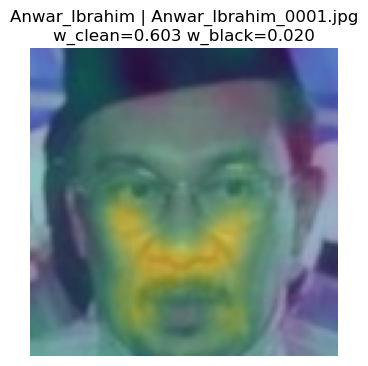

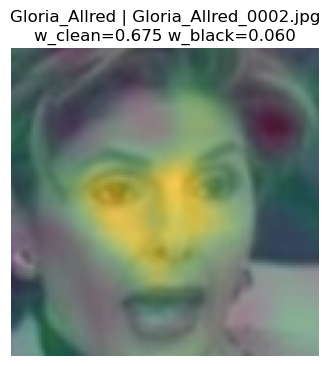

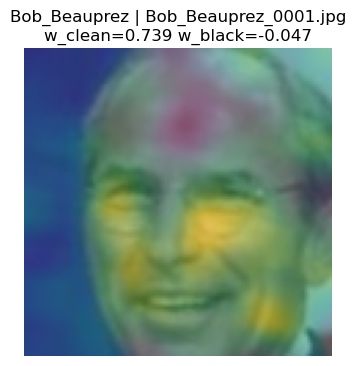

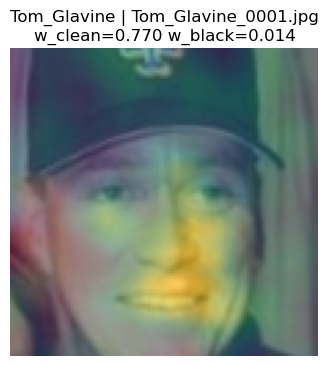

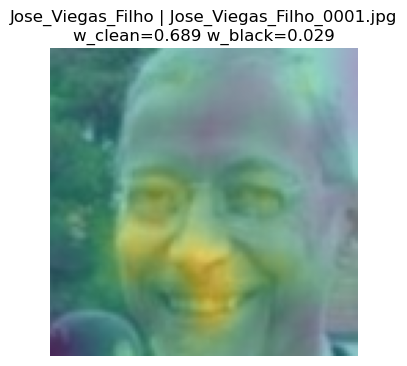

In [12]:
import matplotlib.pyplot as plt

def load_sal(path):
    return np.load(path).astype(np.float32)

for row_i, row in df.iterrows():
    if not isinstance(row.get("saliency_path", None), str) or not os.path.exists(row["saliency_path"]):
        print(f"Skip row {row_i}: no saliency saved")
        continue

    # rebuild chip for display (alignment uses detection on original probe once)
    img = cv2.imread(row["probe_path"])
    chip_bgr = build_aligned_chip_112(img)
    chip_rgb = cv2.cvtColor(chip_bgr, cv2.COLOR_BGR2RGB)

    sal = load_sal(row["saliency_path"])

    plt.figure(figsize=(4,4))
    plt.imshow(chip_rgb)
    plt.imshow(sal, alpha=0.50, vmin=0, vmax=1)
    plt.axis("off")
    plt.title(f"{row['true_id']} | {row['probe_file']}\nw_clean={row['w_clean']:.3f} w_black={row['w_black']:.3f}")
    plt.show()

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def save_overlay_images(true_id: str, probe_path: str, sal_path: str, w_clean: float, w_black: float):
    # rebuild aligned chip (one detection for alignment)
    img = cv2.imread(probe_path)
    if img is None:
        raise ValueError(f"Could not read {probe_path}")
    chip_bgr = build_aligned_chip_112(img)
    chip_rgb = cv2.cvtColor(chip_bgr, cv2.COLOR_BGR2RGB)

    sal = np.load(sal_path).astype(np.float32)  # (112,112) in [0,1]

    safe_id = true_id.replace("/", "_")
    probe_file = os.path.splitext(os.path.basename(probe_path))[0]
    base = f"{safe_id}_{probe_file}_N{N}_s{s}_p{p1}"

    # 1) Save chip (RGB -> BGR for cv2)
    chip_out = os.path.join(FIG_DIR, f"{base}_chip.png")
    cv2.imwrite(chip_out, cv2.cvtColor(chip_rgb, cv2.COLOR_RGB2BGR))

    # 2) Save saliency heatmap image (matplotlib colormap)
    heat_out = os.path.join(FIG_DIR, f"{base}_saliency.png")
    plt.figure(figsize=(4,4))
    plt.imshow(sal, vmin=0, vmax=1)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(heat_out, dpi=200, bbox_inches="tight", pad_inches=0)
    plt.close()

    # 3) Save overlay
    overlay_out = os.path.join(FIG_DIR, f"{base}_overlay.png")
    plt.figure(figsize=(4,4))
    plt.imshow(chip_rgb)
    plt.imshow(sal, alpha=0.50, vmin=0, vmax=1)
    plt.axis("off")
    plt.title(f"{true_id}\nw_clean={w_clean:.3f} w_black={w_black:.3f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(overlay_out, dpi=200, bbox_inches="tight")
    plt.close()

    return chip_out, heat_out, overlay_out

saved = []
for row_i, row in df.iterrows():
    sal_path = row.get("saliency_path", None)
    if not isinstance(sal_path, str) or not os.path.exists(sal_path):
        print(f"Skip row {row_i}: no saliency saved")
        continue

    try:
        chip_out, heat_out, overlay_out = save_overlay_images(
            true_id=row["true_id"],
            probe_path=row["probe_path"],
            sal_path=sal_path,
            w_clean=float(row["w_clean"]),
            w_black=float(row["w_black"]),
        )
        saved.append({
            "true_id": row["true_id"],
            "probe_file": row["probe_file"],
            "chip_png": chip_out,
            "saliency_png": heat_out,
            "overlay_png": overlay_out,
        })
        print("Saved:", overlay_out)
    except Exception as e:
        print("[save error]", row["true_id"], row["probe_path"], "->", repr(e))

# quick peek at saved list
import pandas as pd
pd.DataFrame(saved)

/home/stu10/s7/lpr5476/miniforge3/envs/idai780/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


Saved: results/rise_alignedchip_baseline_multi/figures/Anwar_Ibrahim_Anwar_Ibrahim_0001_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Gloria_Allred_Gloria_Allred_0002_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Bob_Beauprez_Bob_Beauprez_0001_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Tom_Glavine_Tom_Glavine_0001_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Jose_Viegas_Filho_Jose_Viegas_Filho_0001_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Gisele_Bundchen_Gisele_Bundchen_0002_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Carla_Del_Ponte_Carla_Del_Ponte_0001_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/Andre_Agassi_Andre_Agassi_0011_N1000_s8_p0.5_overlay.png
Saved: results/rise_alignedchip_baseline_multi/figures/John_F_Kennedy_Jr_John_F_

,true_id,probe_file,chip_png,saliency_png,overlay_png
0,Anwar_Ibrahim,Anwar_Ibrahim_0001.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
1,Gloria_Allred,Gloria_Allred_0002.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
2,Bob_Beauprez,Bob_Beauprez_0001.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
3,Tom_Glavine,Tom_Glavine_0001.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
4,Jose_Viegas_Filho,Jose_Viegas_Filho_0001.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
...,...,...,...,...,...
1669,Matthew_Perry,Matthew_Perry_0006.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
1670,Lindsey_Graham,Lindsey_Graham_0001.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
1671,Albert_Costa,Albert_Costa_0003.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
1672,Henrique_Meirelles,Henrique_Meirelles_0002.jpg,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...,results/rise_alignedchip_baseline_multi/figure...
